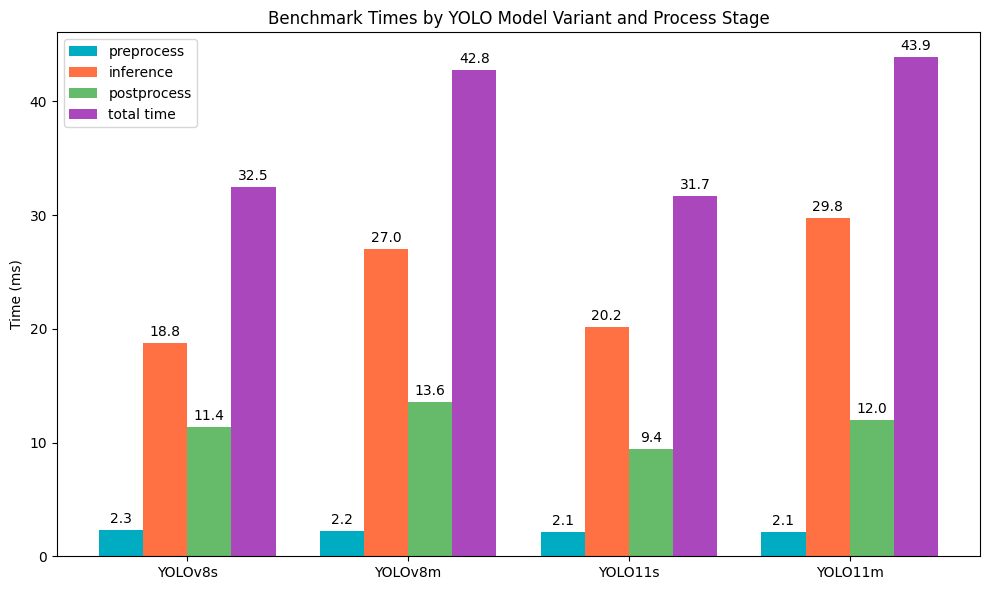

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data (in milliseconds) for each model variant
clusters = ["YOLOv8s", "YOLOv8m", "YOLO11s", "YOLO11m"]
preprocess = [2.32, 2.19, 2.12, 2.15]   
inference = [18.76, 26.99, 20.17, 29.76]  
postprocess = [11.37, 13.58, 9.42, 11.97]    

# Calculate total time for each cluster
total_time = [preprocess[i] + inference[i] + postprocess[i] for i in range(len(clusters))]

# Set positions for clusters and a fixed width for each bar within a cluster
x = np.arange(len(clusters))
width = 0.2

# Create the plot
fig, ax = plt.subplots(figsize=(10,6))


color_pre = "#00ACC1"   # vibrant cyan for preprocess
color_inf = "#FF7043"   # warm orange-red for inference
color_post = "#66BB6A"  # vibrant green for postprocess
color_total = "#AB47BC" # rich purple for total time

# Plot bars with the specified colors
bars_pre = ax.bar(x - 1.5 * width, preprocess, width, color=color_pre, label='preprocess')
bars_inf = ax.bar(x - 0.5 * width, inference, width, color=color_inf, label='inference')
bars_post = ax.bar(x + 0.5 * width, postprocess, width, color=color_post, label='postprocess')
bars_total = ax.bar(x + 1.5 * width, total_time, width, color=color_total, label='total time')

# Set axis labels and title
ax.set_ylabel('Time (ms)')
ax.set_title('Benchmark Times by YOLO Model Variant and Process Stage')
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.legend(loc="upper left")

# Annotate each bar with its height for clarity
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bars_pre)
autolabel(bars_inf)
autolabel(bars_post)
autolabel(bars_total)

# Adjust layout for neatness and display the chart
fig.tight_layout()
plt.show()
